In [2]:
import pandas as pd
import numpy as np

print("Step 1: Loading the dataset")

df = pd.read_csv('AB_NYC_2019.csv')
print("-> Success! File loaded perfectly.")

print("\nStep 2: Cleaning missing data...")
df['name'] = df['name'].fillna("Unknown Listing")
df['host_name'] = df['host_name'].fillna("Unknown Host")
df['reviews_per_month'] = df['reviews_per_month'].fillna(0.0)
df['last_review'] = pd.to_datetime(df['last_review'])
print("-> Success! Missing values handled.")

print("\nStep 3: Fixing text formatting and removing outliers...")
text_cols = ['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()
df.drop_duplicates(inplace=True)
df = df[df['price'] > 0]
df.loc[df['minimum_nights'] > 365, 'minimum_nights'] = 365
print("-> Success! Outliers and text spacing fixed.")

print("\nStep 4: Saving your brand new clean file...")
df.to_csv('AB_NYC_2019_Cleaned.csv', index=False)
print("-> SUCCESS! Your clean file is saved as 'AB_NYC_2019_Cleaned.csv'")

print("\n--- Here is a sneak peek of your cleaned data: ---")
print(df[['name', 'neighbourhood_group', 'price']].head())

Step 1: Loading the dataset...
-> Success! File loaded perfectly.

Step 2: Cleaning missing data...
-> Success! Missing values handled.

Step 3: Fixing text formatting and removing outliers...
-> Success! Outliers and text spacing fixed.

Step 4: Saving your brand new clean file...
-> SUCCESS! Your clean file is saved as 'AB_NYC_2019_Cleaned.csv'

--- Here is a sneak peek of your cleaned data: ---
                                               name neighbourhood_group  price
0                Clean & quiet apt home by the park            Brooklyn    149
1                             Skylit Midtown Castle           Manhattan    225
2               THE VILLAGE OF HARLEM....NEW YORK !           Manhattan    150
3                   Cozy Entire Floor of Brownstone            Brooklyn     89
4  Entire Apt: Spacious Studio/Loft by central park           Manhattan     80


In [3]:
df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)

neighbourhood_group
Manhattan        196.884903
Brooklyn         124.438915
Staten Island    114.812332
Queens            99.517649
Bronx             87.577064
Name: price, dtype: float64

In [4]:
df['room_type'].value_counts()

Entire home/apt    25407
Private room       22319
Shared room         1158
Name: room_type, dtype: int64

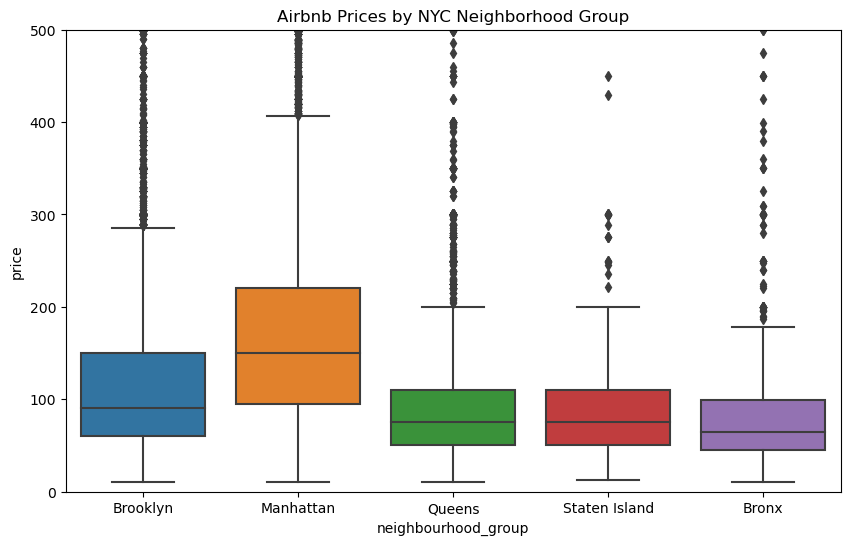

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='neighbourhood_group', y='price')
plt.ylim(0, 500) 
plt.title('Airbnb Prices by NYC Neighborhood Group')
plt.show()